# Team Assignment 8 - ML Deployment 

## Part 1 

Watch pre-class videos:
 - Overview of ML Deployment
 - Docker Containers [Code Demo Walkthrough]

## Part 2 

Put together a presentation tutorial (<7 mins) of your assigned tool/framework/topic. The tutorial should go end-to-end on deployment of a toy ML model. You will present these in class. Remember, you are teaching the class your topic so your presentation should be both educational and engaging. 

Bonus points are available if you optimize your model for deployment (e.g., through quantization or using ONNX for model inference).

Submission

Your submission will be your in-class tutorial presentation. 

Rubric

Presentation (25 points)

- Presentation is clear
- Presentation is engaging
- Presentation is <7 minutes
- Tutorial is clearly planned and well-thought out
- Transitions are handled gracefully
- Approach is easy to follow and understand

## Serverless Deployment using Azure Functions


⛔️ Followed instructions for VS Code deployment here:  https://learn.microsoft.com/en-us/azure/azure-functions/functions-create-function-app-portal?pivots=programming-language-python ... 
  - this did not work out, despite repeated attempts. Failures to create resources due to region (no functions can be created in US east with a paid account???), inexplicable failure to find and load triggers, ....

✅ Pivoted to CLI-based creation given the challenges and inscrutability of the VS code method. See
https://learn.microsoft.com/en-us/cli/azure/install-azure-cli-macos. This worked!

1. installed azure cli, this makes the `az` command available for interacting with azure resources

    ```
    brew update && brew install azure-cli
    ```
   
3. install core tools, this makes the `func` command available to interact with azure core tools

    ```
    brew tap azure/functions
    brew install azure-functions-core-tools@4
    # if upgrading on a machine that has 2.x or 3.x installed:
    brew link --overwrite azure-functions-core-tools@4
    ```
3. created a new venv `python3 -m venv .venv`, python 3.12 virtual environment
3. created a function project ... `func init --python` ...

    ```
    Found Python version 3.11.10 (python3.11).
    The new Python programming model is generally available. Learn more at https://aka.ms/pythonprogrammingmodel
    Writing requirements.txt
    Writing .funcignore
    Writing function_app.py
    .gitignore already exists. Skipped!
    Writing host.json
    Writing local.settings.json
    /Users/jason/Local/school/aipi510-fall24/.vscode/extensions.json already exists. Skipped!
    (.venv) jason@JasonsOficeMini aipi510-fall24 % python --version
    Python 3.12.4
    ```
    - ❗️ note the core tools CLI finds python 3.11, which is annoying as the venv i just created is 3.12 (what is it pointing at? this might cause us problems down the road. proceed for now and see what happens.
5. created a function within the project:

    ```
    (.venv) jason@JasonsOficeMini aipi510-fall24 % func new --name TrackstarsHttp --template "HTTP trigger" --authlevel "anonymous"  
    Appending to /Users/jason/Local/school/aipi510-fall24/function_app.py
    The function "TrackstarsHttp" was created successfully from the "HTTP trigger" template.
    ```
7. attempted to run as instructed ... `func start` and received a cascade of errors... it seems the app uses `Anonymous` as the access level but the actual syntax is `ANONYMOUS` per https://stackoverflow.com/questions/78668008/exception-attributeerror-anonymous-when-starting-a-basic-function-app. This resolves the issue:

    ```
    (.venv) jason@JasonsOficeMini aipi510-fall24 % func start
    Found Python version 3.11.10 (python3.11).
    
    Azure Functions Core Tools
    Core Tools Version:       4.0.6280 Commit hash: N/A +421f0144b42047aa289ce691dc6db4fc8b6143e6 (64-bit)
    Function Runtime Version: 4.834.3.22875
    
    [2024-11-09T14:28:40.758Z] Worker process started and initialized.
    
    Functions:
    
            TrackstarsHttp:  http://localhost:7071/api/TrackstarsHttp
    
    For detailed output, run func with --verbose flag.
    [2024-11-09T14:28:45.710Z] Host lock lease acquired by instance ID '0000000000000000000000008A9E5EBC'.
    [2024-11-09T14:29:02.240Z] Executing 'Functions.TrackstarsHttp' (Reason='This function was programmatically called via the host APIs.', Id=ecc258f4-b35f-43fd-9884-aa5ee4d59ecc)
    [2024-11-09T14:29:02.299Z] Python HTTP trigger function processed a request.
    [2024-11-09T14:29:02.350Z] Executed 'Functions.TrackstarsHttp' (Succeeded, Id=ecc258f4-b35f-43fd-9884-aa5ee4d59ecc, Duration=125ms)
    ```
9. now proceeding with the azure deployment, start by logging in...

    ```
    (.venv) jason@JasonsOficeMini aipi510-fall24 % az login
    A web browser has been opened at https://login.microsoftonline.com/organizations/oauth2/v2.0/authorize. Please continue the login in the web browser. If no web browser is available or if the web browser fails to open, use device code flow with `az login --use-device-code`.
    
    Retrieving tenants and subscriptions for the selection...
    
    [Tenant and subscription selection]
    
    No     Subscription name     Subscription ID                       Tenant
    -----  --------------------  ------------------------------------  -----------------
    [1] *  Pay-As-You-Go         8cb3b59c-c4b0-4de8-8102-804c7463e8ca  Default Directory
    [2]    Primary Subscription  52e0c49d-b9aa-483b-873c-a8d361238ed9  Default Directory
    
    The default is marked with an *; the default tenant is 'Default Directory' and subscription is 'Pay-As-You-Go' (8cb3b59c-c4b0-4de8-8102-804c7463e8ca).
    
    Select a subscription and tenant (Type a number or Enter for no changes): 
    
    Tenant: Default Directory
    Subscription: Pay-As-You-Go (8cb3b59c-c4b0-4de8-8102-804c7463e8ca)
    
    [Announcements]
    With the new Azure CLI login experience, you can select the subscription you want to use more easily. Learn more about it and its configuration at https://go.microsoft.com/fwlink/?linkid=2271236
    
    If you encounter any problem, please open an issue at https://aka.ms/azclibug
    
    [Warning] The login output has been updated. Please be aware that it no longer displays the full list of available subscriptions by default.
    ```
10. created a resource group:

    ```
    (.venv) jason@JasonsOficeMini aipi510-fall24 % az group create --name TrackstarsFunctionApp-rg --location "Central US"
    {
      "id": "/subscriptions/8cb3b59c-c4b0-4de8-8102-804c7463e8ca/resourceGroups/TrackstarsFunctionApp-rg",
      "location": "centralus",
      "managedBy": null,
      "name": "TrackstarsFunctionApp-rg",
      "properties": {
        "provisioningState": "Succeeded"
      },
      "tags": null,
      "type": "Microsoft.Resources/resourceGroups"
    }
    ```
11. created a storage account:

    ```
    (.venv) jason@JasonsOficeMini aipi510-fall24 % az storage account create --name trackstarsstorage --location "Central US" --resource-group TrackstarsFunctionApp-rg --sku Standard_LRS 
    {
      "accessTier": "Hot",
      "accountMigrationInProgress": null,
      "allowBlobPublicAccess": false,
      "allowCrossTenantReplication": false,
      "allowSharedKeyAccess": null,
      "allowedCopyScope": null,
      "azureFilesIdentityBasedAuthentication": null,
      "blobRestoreStatus": null,
      "creationTime": "2024-11-09T14:40:58.468734+00:00",
      "customDomain": null,
      "defaultToOAuthAuthentication": null,
      "dnsEndpointType": null,
      "enableExtendedGroups": null,
      "enableHttpsTrafficOnly": true,
      "enableNfsV3": null,
      "encryption": {
        "encryptionIdentity": null,
        "keySource": "Microsoft.Storage",
        "keyVaultProperties": null,
        "requireInfrastructureEncryption": null,
        "services": {
          "blob": {
            "enabled": true,
            "keyType": "Account",
            "lastEnabledTime": "2024-11-09T14:40:58.874981+00:00"
          },
          "file": {
            "enabled": true,
            "keyType": "Account",
            "lastEnabledTime": "2024-11-09T14:40:58.874981+00:00"
          },
          "queue": null,
          "table": null
        }
      },
      "extendedLocation": null,
      "failoverInProgress": null,
      "geoReplicationStats": null,
      "id": "/subscriptions/8cb3b59c-c4b0-4de8-8102-804c7463e8ca/resourceGroups/TrackstarsFunctionApp-rg/providers/Microsoft.Storage/storageAccounts/trackstarsstorage",
      "identity": null,
      "immutableStorageWithVersioning": null,
      "isHnsEnabled": null,
      "isLocalUserEnabled": null,
      "isSftpEnabled": null,
      "isSkuConversionBlocked": null,
      "keyCreationTime": {
        "key1": "2024-11-09T14:40:58.624983+00:00",
        "key2": "2024-11-09T14:40:58.624983+00:00"
      },
      "keyPolicy": null,
      "kind": "StorageV2",
      "largeFileSharesState": null,
      "lastGeoFailoverTime": null,
      "location": "centralus",
      "minimumTlsVersion": "TLS1_0",
      "name": "trackstarsstorage",
      "networkRuleSet": {
        "bypass": "AzureServices",
        "defaultAction": "Allow",
        "ipRules": [],
        "ipv6Rules": [],
        "resourceAccessRules": null,
        "virtualNetworkRules": []
      },
      "primaryEndpoints": {
        "blob": "https://trackstarsstorage.blob.core.windows.net/",
        "dfs": "https://trackstarsstorage.dfs.core.windows.net/",
        "file": "https://trackstarsstorage.file.core.windows.net/",
        "internetEndpoints": null,
        "microsoftEndpoints": null,
        "queue": "https://trackstarsstorage.queue.core.windows.net/",
        "table": "https://trackstarsstorage.table.core.windows.net/",
        "web": "https://trackstarsstorage.z19.web.core.windows.net/"
      },
      "primaryLocation": "centralus",
      "privateEndpointConnections": [],
      "provisioningState": "Succeeded",
      "publicNetworkAccess": null,
      "resourceGroup": "TrackstarsFunctionApp-rg",
      "routingPreference": null,
      "sasPolicy": null,
      "secondaryEndpoints": null,
      "secondaryLocation": null,
      "sku": {
        "name": "Standard_LRS",
        "tier": "Standard"
      },
      "statusOfPrimary": "available",
      "statusOfSecondary": null,
      "storageAccountSkuConversionStatus": null,
      "tags": {},
      "type": "Microsoft.Storage/storageAccounts"
    }
    ```

10. created function app

    ```
    (.venv) jason@JasonsOficeMini aipi510-fall24 % az functionapp create --resource-group TrackstarsFunctionApp-rg --consumption-plan-location centralus --runtime python --runtime-version 3.11 --functions-version 4 --name TrackstarsFunctionApp --os-type linux --storage-account trackstarsstorage
    
    /opt/homebrew/Cellar/azure-cli/2.65.0_2/libexec/lib/python3.11/site-packages/paramiko/pkey.py:100: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
      "cipher": algorithms.TripleDES,
    /opt/homebrew/Cellar/azure-cli/2.65.0_2/libexec/lib/python3.11/site-packages/paramiko/transport.py:259: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
      "class": algorithms.TripleDES,
    Your Linux function app 'TrackstarsFunctionApp', that uses a consumption plan has been successfully created but is not active until content is published using Azure Portal or the Functions Core Tools.
    Application Insights "TrackstarsFunctionApp" was created for this Function App. You can visit https://portal.azure.com/#resource/subscriptions/8cb3b59c-c4b0-4de8-8102-804c7463e8ca/resourceGroups/TrackstarsFunctionApp-rg/providers/microsoft.insights/components/TrackstarsFunctionApp/overview to view your Application Insights component
    App settings have been redacted. Use `az webapp/logicapp/functionapp config appsettings list` to view.
    {
      "availabilityState": "Normal",
      "clientAffinityEnabled": false,
      "clientCertEnabled": false,
      "clientCertExclusionPaths": null,
      "clientCertMode": "Required",
      "cloningInfo": null,
      "containerSize": 0,
      "customDomainVerificationId": "A723E10661FB802BADB852CADCB0FB33F8D20C6042F2CE9C6F7BAB419E9DB4F9",
      "dailyMemoryTimeQuota": 0,
      "daprConfig": null,
      "defaultHostName": "trackstarsfunctionapp.azurewebsites.net",
      "enabled": true,
      "enabledHostNames": [
        "trackstarsfunctionapp.azurewebsites.net",
        "trackstarsfunctionapp.scm.azurewebsites.net"
      ],
      "extendedLocation": null,
      "hostNameSslStates": [
        {
          "certificateResourceId": null,
          "hostType": "Standard",
          "ipBasedSslResult": null,
          "ipBasedSslState": "NotConfigured",
          "name": "trackstarsfunctionapp.azurewebsites.net",
          "sslState": "Disabled",
          "thumbprint": null,
          "toUpdate": null,
          "toUpdateIpBasedSsl": null,
          "virtualIPv6": null,
          "virtualIp": null
        },
        {
          "certificateResourceId": null,
          "hostType": "Repository",
          "ipBasedSslResult": null,
          "ipBasedSslState": "NotConfigured",
          "name": "trackstarsfunctionapp.scm.azurewebsites.net",
          "sslState": "Disabled",
          "thumbprint": null,
          "toUpdate": null,
          "toUpdateIpBasedSsl": null,
          "virtualIPv6": null,
          "virtualIp": null
        }
      ],
      "hostNames": [
        "trackstarsfunctionapp.azurewebsites.net"
      ],
      "hostNamesDisabled": false,
      "hostingEnvironmentProfile": null,
      "httpsOnly": false,
      "hyperV": false,
      "id": "/subscriptions/8cb3b59c-c4b0-4de8-8102-804c7463e8ca/resourceGroups/TrackstarsFunctionApp-rg/providers/Microsoft.Web/sites/TrackstarsFunctionApp",
      "identity": null,
      "inProgressOperationId": null,
      "isDefaultContainer": null,
      "isXenon": false,
      "keyVaultReferenceIdentity": "SystemAssigned",
      "kind": "functionapp,linux",
      "lastModifiedTimeUtc": "2024-11-09T14:44:12.333333",
      "location": "centralus",
      "managedEnvironmentId": null,
      "maxNumberOfWorkers": null,
      "name": "TrackstarsFunctionApp",
      "outboundIpAddresses": "40.122.169.200,104.208.27.4,40.122.42.64,23.99.130.19,13.89.172.4",
      "possibleOutboundIpAddresses": "40.122.169.200,104.208.27.4,40.122.42.64,23.99.130.19,13.67.176.18,104.208.28.216,40.122.168.112,40.122.169.80,23.99.159.248,20.118.17.81,20.118.19.166,20.118.19.182,20.118.20.77,20.118.20.179,20.118.20.230,20.118.21.220,20.118.22.146,20.118.22.148,20.118.22.161,20.118.22.177,20.118.22.227,13.89.172.4",
      "publicNetworkAccess": null,
      "redundancyMode": "None",
      "repositorySiteName": "TrackstarsFunctionApp",
      "reserved": true,
      "resourceConfig": null,
      "resourceGroup": "TrackstarsFunctionApp-rg",
      "scmSiteAlsoStopped": false,
      "serverFarmId": "/subscriptions/8cb3b59c-c4b0-4de8-8102-804c7463e8ca/resourceGroups/TrackstarsFunctionApp-rg/providers/Microsoft.Web/serverfarms/CentralUSLinuxDynamicPlan",
      "siteConfig": {
        "acrUseManagedIdentityCreds": false,
        "acrUserManagedIdentityId": null,
        "alwaysOn": false,
        "antivirusScanEnabled": null,
        "apiDefinition": null,
        "apiManagementConfig": null,
        "appCommandLine": null,
        "appSettings": null,
        "autoHealEnabled": null,
        "autoHealRules": null,
        "autoSwapSlotName": null,
        "azureMonitorLogCategories": null,
        "azureStorageAccounts": null,
        "clusteringEnabled": false,
        "connectionStrings": null,
        "cors": null,
        "customAppPoolIdentityAdminState": null,
        "customAppPoolIdentityTenantState": null,
        "defaultDocuments": null,
        "detailedErrorLoggingEnabled": null,
        "documentRoot": null,
        "elasticWebAppScaleLimit": null,
        "experiments": null,
        "fileChangeAuditEnabled": null,
        "ftpsState": null,
        "functionAppScaleLimit": 0,
        "functionsRuntimeScaleMonitoringEnabled": null,
        "handlerMappings": null,
        "healthCheckPath": null,
        "http20Enabled": false,
        "http20ProxyFlag": null,
        "httpLoggingEnabled": null,
        "ipSecurityRestrictions": [
          {
            "action": "Allow",
            "description": "Allow all access",
            "headers": null,
            "ipAddress": "Any",
            "name": "Allow all",
            "priority": 2147483647,
            "subnetMask": null,
            "subnetTrafficTag": null,
            "tag": null,
            "vnetSubnetResourceId": null,
            "vnetTrafficTag": null
          }
        ],
        "ipSecurityRestrictionsDefaultAction": null,
        "javaContainer": null,
        "javaContainerVersion": null,
        "javaVersion": null,
        "keyVaultReferenceIdentity": null,
        "limits": null,
        "linuxFxVersion": "",
        "loadBalancing": null,
        "localMySqlEnabled": null,
        "logsDirectorySizeLimit": null,
        "machineKey": null,
        "managedPipelineMode": null,
        "managedServiceIdentityId": null,
        "metadata": null,
        "minTlsCipherSuite": null,
        "minTlsVersion": null,
        "minimumElasticInstanceCount": 0,
        "netFrameworkVersion": null,
        "nodeVersion": null,
        "numberOfWorkers": 1,
        "phpVersion": null,
        "powerShellVersion": null,
        "preWarmedInstanceCount": null,
        "publicNetworkAccess": null,
        "publishingPassword": null,
        "publishingUsername": null,
        "push": null,
        "pythonVersion": null,
        "remoteDebuggingEnabled": null,
        "remoteDebuggingVersion": null,
        "requestTracingEnabled": null,
        "requestTracingExpirationTime": null,
        "routingRules": null,
        "runtimeADUser": null,
        "runtimeADUserPassword": null,
        "scmIpSecurityRestrictions": [
          {
            "action": "Allow",
            "description": "Allow all access",
            "headers": null,
            "ipAddress": "Any",
            "name": "Allow all",
            "priority": 2147483647,
            "subnetMask": null,
            "subnetTrafficTag": null,
            "tag": null,
            "vnetSubnetResourceId": null,
            "vnetTrafficTag": null
          }
        ],
        "scmIpSecurityRestrictionsDefaultAction": null,
        "scmIpSecurityRestrictionsUseMain": null,
        "scmMinTlsCipherSuite": null,
        "scmMinTlsVersion": null,
        "scmSupportedTlsCipherSuites": null,
        "scmType": null,
        "sitePort": null,
        "sitePrivateLinkHostEnabled": null,
        "storageType": null,
        "supportedTlsCipherSuites": null,
        "tracingOptions": null,
        "use32BitWorkerProcess": null,
        "virtualApplications": null,
        "vnetName": null,
        "vnetPrivatePortsCount": null,
        "vnetRouteAllEnabled": null,
        "webSocketsEnabled": null,
        "websiteTimeZone": null,
        "winAuthAdminState": null,
        "winAuthTenantState": null,
        "windowsConfiguredStacks": null,
        "windowsFxVersion": null,
        "xManagedServiceIdentityId": null
      },
      "slotSwapStatus": null,
      "state": "Running",
      "storageAccountRequired": false,
      "suspendedTill": null,
      "tags": null,
      "targetSwapSlot": null,
      "trafficManagerHostNames": null,
      "type": "Microsoft.Web/sites",
      "usageState": "Normal",
      "virtualNetworkSubnetId": null,
      "vnetContentShareEnabled": false,
      "vnetImagePullEnabled": false,
      "vnetRouteAllEnabled": false,
      "workloadProfileName": null
    }
    ```


## Toy Model Setup

We use the Onnx model zoo and follow the sample model setup outlined in the Onnx example here: https://github.com/onnx/onnx-docker/blob/master/onnx-ecosystem/inference_demos/resnet50_modelzoo_onnxruntime_inference.ipynb

In [27]:
import numpy as np    # we're going to use numpy to process input and output data
import onnxruntime    # to inference ONNX models, we use the ONNX Runtime
import onnx
from onnx import numpy_helper
import urllib.request
import json
import time

# display images in notebook
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

%matplotlib inline

In [28]:
onnx_model_url = "https://s3.amazonaws.com/onnx-model-zoo/resnet/resnet50v2/resnet50v2.tar.gz"
imagenet_labels_url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"

urllib.request.urlretrieve(onnx_model_url, filename="resnet50v2.tar.gz")
urllib.request.urlretrieve(imagenet_labels_url, filename="imagenet-simple-labels.json")

!tar xvzf resnet50v2.tar.gz

x resnet50v2/
x resnet50v2/resnet50v2.onnx
x resnet50v2/test_data_set_0/
x resnet50v2/test_data_set_1/
x resnet50v2/test_data_set_2/
x resnet50v2/test_data_set_2/input_0.pb
x resnet50v2/test_data_set_2/output_0.pb
x resnet50v2/test_data_set_1/input_0.pb
x resnet50v2/test_data_set_1/output_0.pb
x resnet50v2/test_data_set_0/input_0.pb
x resnet50v2/test_data_set_0/output_0.pb


In [29]:
!ls -l 

total 198096
drwxr-xr-x  3 jason  staff        96 Nov  9 09:27 __pycache__
-rw-r--r--  1 jason  staff       886 Nov  9 09:27 function_app.py
-rw-r--r--  1 jason  staff       288 Nov  9 09:18 host.json
-rw-r--r--  1 jason  staff     14209 Nov  9 11:43 imagenet-simple-labels.json
drwxr-xr-x  7 jason  staff       224 Nov  9 11:40 images
-rw-r--r--  1 jason  staff       173 Nov  9 09:18 local.settings.json
-rw-r--r--  1 jason  staff       203 Nov  9 09:18 requirements.txt
drwxr-xr-x  6 jason  staff       192 Nov  9 11:43 resnet50v2
-rw-r--r--  1 jason  staff  96452466 Nov  9 11:43 resnet50v2.tar.gz
-rw-------@ 1 jason  staff      9722 Nov  9 11:21 ta8-trackstars.drawio
-rw-r--r--  1 jason  staff    649514 Nov  9 11:43 ta8-trackstars.ipynb


In [30]:
!ls -lahF resnet50v2

total 200088
drwxr-xr-x   6 jason  staff   192B Nov  9 11:43 ./
drwxr-xr-x  20 jason  staff   640B Nov  9 11:43 ../
-rw-r--r--@  1 jason  staff    98M Jun 29  2018 resnet50v2.onnx
drwxr-xr-x   4 jason  staff   128B Nov  9 11:43 test_data_set_0/
drwxr-xr-x   4 jason  staff   128B Nov  9 11:43 test_data_set_1/
drwxr-xr-x   4 jason  staff   128B Nov  9 11:43 test_data_set_2/


In [31]:
test_data_dir = 'resnet50v2/test_data_set'
test_data_num = 3

In [32]:
import glob
import os

# Load inputs
inputs = []
for i in range(test_data_num):
    input_file = os.path.join(test_data_dir + '_{}'.format(i), 'input_0.pb')
    tensor = onnx.TensorProto()
    with open(input_file, 'rb') as f:
        tensor.ParseFromString(f.read())
        inputs.append(numpy_helper.to_array(tensor))

print('Loaded {} inputs successfully.'.format(test_data_num))
        
# Load reference outputs

ref_outputs = []
for i in range(test_data_num):
    output_file = os.path.join(test_data_dir + '_{}'.format(i), 'output_0.pb')
    tensor = onnx.TensorProto()
    with open(output_file, 'rb') as f:
        tensor.ParseFromString(f.read())    
        ref_outputs.append(numpy_helper.to_array(tensor))
        
print('Loaded {} reference outputs successfully.'.format(test_data_num))

Loaded 3 inputs successfully.
Loaded 3 reference outputs successfully.


In [33]:
# Run the model on the backend
session = onnxruntime.InferenceSession('resnet50v2/resnet50v2.onnx', None)

# get the name of the first input of the model
input_name = session.get_inputs()[0].name  

print('Input Name:', input_name)

Input Name: data


In [34]:
%%time
outputs = [session.run([], {input_name: inputs[i]})[0] for i in range(test_data_num)]

CPU times: user 366 ms, sys: 11.7 ms, total: 377 ms
Wall time: 99.7 ms


In [35]:
print('Predicted {} results.'.format(len(outputs)))

# Compare the results with reference outputs up to 4 decimal places
for ref_o, o in zip(ref_outputs, outputs):
    np.testing.assert_almost_equal(ref_o, o, 4)
    
print('ONNX Runtime outputs are similar to reference outputs!')

Predicted 3 results.
ONNX Runtime outputs are similar to reference outputs!


In [36]:
def load_labels(path):
    with open(path) as f:
        data = json.load(f)
    return np.asarray(data)

def preprocess(input_data):
    # convert the input data into the float32 input
    img_data = input_data.astype('float32')

    #normalize
    mean_vec = np.array([0.485, 0.456, 0.406])
    stddev_vec = np.array([0.229, 0.224, 0.225])
    norm_img_data = np.zeros(img_data.shape).astype('float32')
    for i in range(img_data.shape[0]):
        norm_img_data[i,:,:] = (img_data[i,:,:]/255 - mean_vec[i]) / stddev_vec[i]
        
    #add batch channel
    norm_img_data = norm_img_data.reshape(1, 3, 224, 224).astype('float32')
    return norm_img_data

def softmax(x):
    x = x.reshape(-1)
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

def postprocess(result):
    return softmax(np.array(result)).tolist()

Image size:  (224, 224)


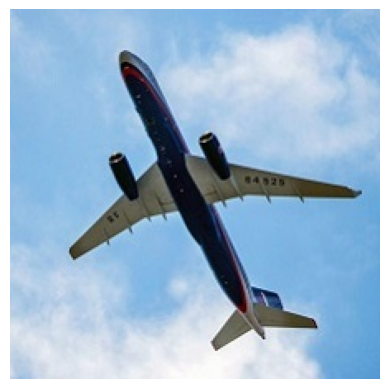

In [79]:
labels = load_labels('imagenet-simple-labels.json')
# image = Image.open('images/dog.jpg')
image = Image.open('images/plane.jpg')

print("Image size: ", image.size)
plt.axis('off')
display_image = plt.imshow(image)
image_data = np.array(image).transpose(2, 0, 1)
input_data = preprocess(image_data)

In [38]:
start = time.time()
raw_result = session.run([], {input_name: input_data})
end = time.time()
res = postprocess(raw_result)

In [65]:
inference_time = np.round((end - start) * 1000, 2)
idx = np.argmax(res)

print('========================================')
print('Final top prediction is: ' + labels[idx])
print('========================================')

print('========================================')
print('Inference time: ' + str(inference_time) + " ms")
print('========================================')

sort_idx = np.flip(np.squeeze(np.argsort(res)))
print('============ Top 5 labels are: ============================')
print(labels[sort_idx[:5]])
print('===========================================================')

Final top prediction is: airliner
Inference time: 52.78 ms
============ Top 5 labels are: ============================
['airliner' 'wing' 'military aircraft' 'space shuttle' 'projectile']


## Image resizing in support of a toy deployment

In [41]:
# Resnet50 only accepts images of 226x226 pixels... accept an arbitrary image size and scale down 

In [42]:
import cv2

In [43]:
src_image = Image.open('images/horses.jpg')

In [44]:
src_image.size

(750, 500)

In [48]:
src_array = np.array(src_image) 

In [91]:
scaled_image = cv2.resize(src_array, (224,224), interpolation=cv2.INTER_CUBIC)

In [92]:
scaled_image.size

150528

In [93]:
pil_image = Image.fromarray(scaled_image) 

In [94]:
type(pil_image) 

PIL.Image.Image

In [95]:
pil_image.size

(224, 224)

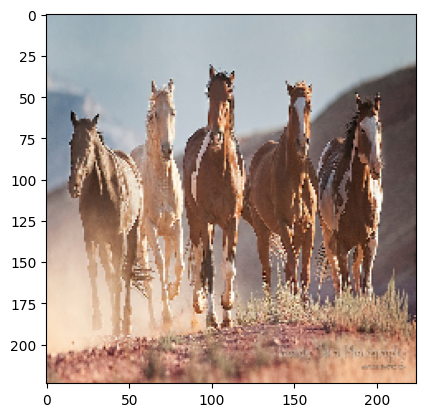

In [101]:
plt.imshow(pil_image) 

In [104]:
def resnet_scale(image): 
    pass
    
def resnet_classify(image): 
    """
    Classify
    """
    image_data = np.array(image).transpose(2, 0, 1)
    input_data = preprocess(image_data)

    start = time.time()
    raw_result = session.run([], {input_name: input_data})
    end = time.time()
    res = postprocess(raw_result)

    inference_time = np.round((end - start) * 1000, 2)
    idx = np.argmax(res)

    print('========================================')
    print('Final top prediction is: ' + labels[idx])
    print('========================================')
    
    print('========================================')
    print('Inference time: ' + str(inference_time) + " ms")
    print('========================================')

    sort_idx = np.flip(np.squeeze(np.argsort(res)))
    print('============ Top 5 labels are: ============================')
    print(labels[sort_idx[:5]])
    print('===========================================================')

In [106]:
resnet_classify(scaled_image)

Final top prediction is: dromedary
Inference time: 117.35 ms
============ Top 5 labels are: ============================
['dromedary' 'common sorrel' 'split-rail fence' 'llama' 'shipwreck']


## Toy Model Inference via Azure Functions

In [40]:
# TODO